# LDH Adsorption – RR % without the V descriptor
Variant experiment: the primary interpolation protocol with the McGowan volume **V actually dropped**.

> The previous version of this notebook *claimed* to drop V but the code explicitly kept it (`if f != "V"` filter). The pipeline now asserts V is absent.

> **Scope of the claim.** The dataset's 1342 rows come from **59 source studies**: within one
> study, the material and pollutant descriptors are constant and only the operating conditions
> (pH, temperature, time, dosage, Ci) vary. These models are therefore trained and validated to
> **predict RR % for *studied* material–pollutant systems at new operating conditions**
> (within-system interpolation, row-level split with exact-duplicate rows removed).
> They are **not** validated for screening unseen materials or pollutants: a grouped split by
> source study (reported in the main notebook as a limitation analysis) shows near-zero
> cross-study R². Do not cite the interpolation metrics as evidence of screening power.

> **Methodology notes (rewrite, 2026-09):** rebuilt on the shared
> [`ldh_pipeline.py`](ldh_pipeline.py) module after a code review. Scores are reported as three
> honestly-labeled numbers (train / CV validation / hold-out test); KNN imputation, scaling and
> encoding live inside each model's Pipeline (fit on training folds only); RR % is normalized
> range-aware to [0, 100]; exact feature-duplicate rows are removed before splitting; every
> split, CV fold, and Optuna sampler is seeded; each experiment saves models + scores + config
> under its own `Model/<experiment_name>/` folder.

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings('ignore')
# On Colab: clone/mount the repo and point this at its notebooks/ folder.
sys.path.insert(0, str(Path.cwd()))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ldh_pipeline as lp

plt.rcParams.update({
    'figure.facecolor': '#F8F9FA', 'axes.facecolor': '#FAFAFA',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titleweight': 'bold', 'axes.titlesize': 12,
})
SEED = lp.SEED
print('Data dir :', lp.DATA_DIR)
print('Model dir:', lp.MODEL_DIR)

Data dir : /home/trunght/workspace/researches/Green-X Project-BaoTien/Data
Model dir: /home/trunght/workspace/researches/Green-X Project-BaoTien/Model


In [2]:
df = lp.load_data(lp.DATA_DIR / '20260804_Data_Adsorption.xlsx')
cfg = lp.ExperimentConfig(name='no_V_interp_42', split_mode='row', dedup_features=True,
                          drop_features=['V'],
                          models=("LR", "KNN", "ANN", "Cubist", "RF", "XGB", "HistGB"))
run = lp.run_experiment(cfg, df)
assert 'V' not in run['X_train'].columns
run['table'].round(3)

[no_V_interp_42] dropped 83 exact feature-duplicate rows
[no_V_interp_42] split=row  train=1007  test=252  features=29
--- Optuna tuning RF (30 trials) ---


[*] RF best params: {'n_estimators': 355, 'max_depth': 13, 'min_samples_leaf': 3}
--- Optuna tuning XGB (30 trials) ---


[*] XGB best params: {'n_estimators': 347, 'learning_rate': 0.11620129723728588, 'max_depth': 9, 'min_child_weight': 7}
--- Optuna tuning HistGB (30 trials) ---


[*] HistGB best params: {'max_iter': 518, 'learning_rate': 0.10744522779607346, 'max_depth': 12, 'min_samples_leaf': 8}
--- LR ---


    Train      R2  0.4408 | MAE  16.8995
    CV (valid) R2  0.3877 | MAE  17.4676
    Test       R2  0.4429 | MAE  17.1406

--- KNN ---


...

    Train      R2  0.9254 | MAE   4.2524
    CV (valid) R2  0.7763 | MAE   8.4957
    Test       R2  0.7919 | MAE   8.1593

--- RF ---


    Train      R2  0.9026 | MAE   5.7579
    CV (valid) R2  0.7722 | MAE   9.0926
    Test       R2  0.7989 | MAE   8.3659

--- XGB ---


    Train      R2  0.9886 | MAE   1.5766
    CV (valid) R2  0.8425 | MAE   6.9365
    Test       R2  0.8724 | MAE   5.4727

--- HistGB ---


    Train      R2  0.9928 | MAE   1.2536
    CV (valid) R2  0.8396 | MAE   6.9302
    Test       R2  0.8710 | MAE   5.4925



,train_r2,cv_r2,test_r2,train_mae,cv_mae,test_mae,test_rmse
XGB,0.989,0.843,0.872,1.577,6.937,5.473,10.084
HistGB,0.993,0.840,0.871,1.254,6.930,5.493,10.138
KNN,0.996,0.728,0.765,0.082,8.132,7.678,13.673
Cubist,0.925,0.776,0.792,4.252,8.496,8.159,12.877
RF,0.903,0.772,0.799,5.758,9.093,8.366,12.660
ANN,0.616,0.506,0.566,13.007,15.084,13.891,18.593
LR,0.441,0.388,0.443,16.899,17.468,17.141,21.071


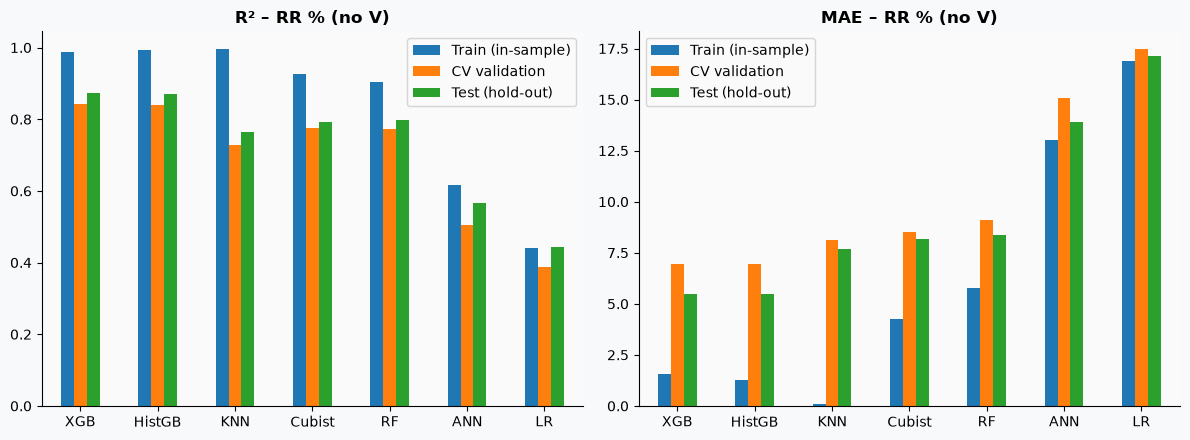

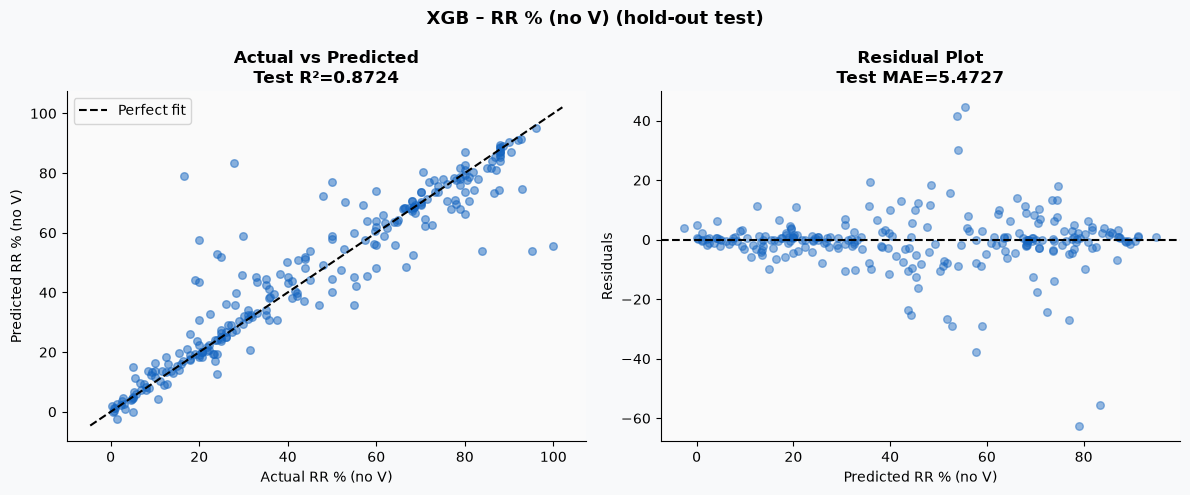

In [3]:
lp.plot_model_comparison(run['table'], 'RR % (no V)',
                         out_path=run['out_dir'] / 'model_results.png')
best = run['table'].index[0]
lp.plot_parity(run['results'][best], 'RR % (no V)',
               out_path=run['out_dir'] / 'best_model_parity.png')

In [4]:
ranks = lp.permutation_ranks(run['results'], run['X_test'], run['y_test'])
ranks.to_csv(run['out_dir'] / 'permutation_importance.csv')
ranks.sort_values('HistGB')

,LR,KNN,ANN,Cubist,RF,XGB,HistGB
AD g/L,26,1,26,1,1,1,1
Time h,18,2,1,2,2,2,2
Ci mg/L,23,4,18,3,3,5,3
pH,24,3,4,5,6,4,4
Log Kow,11,11,19,10,5,3,5
pHpzc,21,7,16,14,4,7,6
BET m2/g,25,6,5,8,7,6,7
PV cm3/g,10,16,14,4,8,11,8
average Pauling electronegativity,15,22,2,11,9,13,9
d(003) nm,14,5,6,6,12,10,10
